In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
import openai
import base64
import io
import os
from dotenv import load_dotenv

load_dotenv()
openai.my_api_key = os.getenv('OPENAI_API_KEY')

In [2]:
# Open model from folder
with open("files/model.pkl", 'rb') as file_1:
  model = pickle.load(file_1)

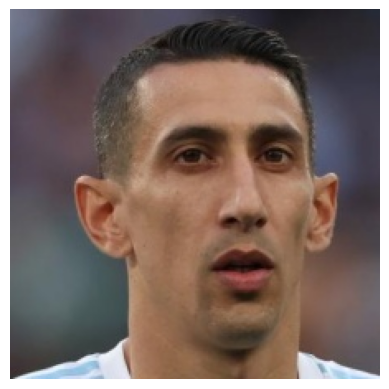

In [3]:
# Pick inference image and illustrate (Can be replaced with another image)
test_image = mpimg.imread('files/TE__ovale__ovale 0002.jpg')
plt.imshow(test_image)
plt.axis("off")
plt.show()

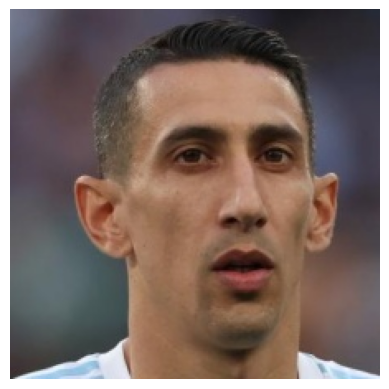

In [4]:
target_size = (224, 224)

def resize(image):
    image = cv2.resize(image, target_size)
    return image
test_image = resize(test_image)
plt.imshow(test_image)
plt.axis("off")
plt.show()

test_image = test_image / 255.

> ### Insight — praproses, dan celah terbesar di pipeline ini
>
> Di sini gambar hanya di-`cv2.resize` ke 224x224 lalu dibagi 255. 
>
>
>
> Perbaikannya: pindahkan `crop_face()` dari notebook prep ke satu modul bersama
> (misalnya `face_crop.py`), lalu panggil fungsi yang sama di prep dan di sini.
> Selama praproses training dan inference ditulis dua kali di dua tempat berbeda,
> keduanya akan menyimpang cepat atau lambat.

In [5]:
# Predict an image

y_pred = model.predict(np.expand_dims(test_image, 0))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


array([[7.9397631e-01, 2.0417112e-01, 1.7891771e-03, 6.3450592e-05]],
      dtype=float32)

In [6]:
# Probability for each class
class_names = class_names = ["ovale", "rectangular", "round", "square"]
y_pred_df = pd.DataFrame(y_pred, columns=class_names)
y_pred_df

,ovale,rectangular,round,square
0,0.793976,0.204171,0.001789,0.000063


In [7]:
# Get class prediction

y_pred_class = np.argmax(y_pred[0])
y_pred_class_name = class_names[np.argmax(y_pred[0])]

print('Prediction - Class       : ', y_pred_class)
print('Prediction - Class Name  : ', y_pred_class_name)

Prediction - Class       :  0
Prediction - Class Name  :  ovale


> ### Insight — membaca keluaran model
>
> Untuk gambar contoh ini: ovale 0,794 — rectangular 0,204 — round 0,002 —
> square 0,00006. Prediksinya benar; file-nya memang berlabel ovale.
>
> Yang lebih menarik adalah bentuk distribusinya. Model membagi hampir seluruh
> keyakinannya antara `ovale` dan `rectangular` (gabungan 0,998) dan praktis
> menolkan `round` dan `square`. Ini konsisten dengan hasil test set di notebook
> training, di mana `rectangular` memang kelas yang paling sering menyerap kasus
> meragukan.
>
> `np.argmax` juga mengambil kelas teratas tanpa ambang apa pun. Prediksi dengan
> probabilitas tertinggi 0,30 diperlakukan sama yakinnya dengan yang 0,95. Untuk
> aplikasi nyata, ambang minimum (misalnya menolak menjawab bila di bawah 0,5)


In [ ]:
#Source : https://clippersbarbershop-tx.com/mens-haircuts-by-face-shape/

hairstyle = None

if y_pred_class_name == "square":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: Textured crop, quiff, high fade, undercut, side part, pompadour")
    hairstyle = "Textured crop, quiff, high fade, undercut, side part, and pompadour"

if y_pred_class_name == "ovale":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: Crew cut, textured crop, side part taper, undercut, pompadour")
    hairstyle = "Crew cut, textured crop, side part taper, undercut, and pompadour"

if y_pred_class_name == "round":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: High fade with textured top, pompadour, quiff, side part, faux hawk")
    hairstyle = "High fade with textured top, pompadour, quiff, side part, and faux hawk"

if y_pred_class_name == "rectangular":
    print("Face Shape:",y_pred_class_name)
    print("Recommended Hairstyle: Layered or medium-length styles, side part with texture, shoulder-length/shaggy styles")
    hairstyle = "Layered or medium-length styles, side part with texture, and shoulder-length/shaggy styles"


Face Shape: ovale
Recommended Hairstyle: Crew cut, textured crop, side part taper, undercut, pompadour


> ### Insight — pemetaan ke rekomendasi
>
> Pemetaan bentuk wajah ke gaya rambut di sini murni aturan `if`, bukan hasil
> model, dan bersumber dari satu artikel barbershop. Untuk prototipe ini pilihan
> yang wajar — tidak ada data pelatihan untuk "gaya rambut yang cocok", jadi tidak
> ada yang bisa dipelajari model. Tapi statusnya perlu disebut terang-terangan:
> ini konvensi gaya, bukan temuan, dan dari satu sumber saja.
>
> Dua catatan teknis:
>
> - Rekomendasi yang ditampilkan berisi 5-6 gaya, tapi variabel `hairstyle` hanya
>   mengambil satu untuk diteruskan ke tahap generatif. Pengguna tidak diberi
>   pilihan, padahal daftarnya sudah ada di depan mata.
> - Seluruh rekomendasi berorientasi gaya rambut pria, sesuai sumber data
>   `dataset/men` di tahap prep. Batasan ini sebaiknya dinyatakan, bukan dibiarkan
>   tersirat.

Loading...


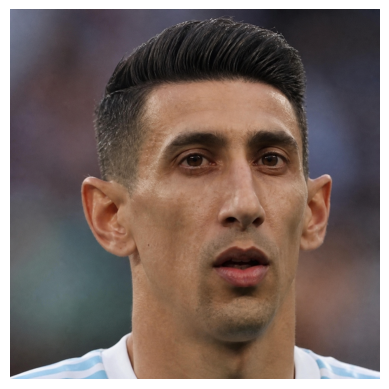

In [9]:
client = openai.OpenAI(api_key=openai.my_api_key )

prompt = f"if there is a face of a man in the photo, change his hairstyle into {hairstyle}, if not send response : no  male face detected, and dont generate any picture"

img_uint8 = (test_image*255).astype(np.uint8)
img_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

base64_image1 = base64.b64encode(cv2.imencode(".jpg", img_uint8)[1]).decode("utf-8")

print("Loading...")
response = client.responses.create(
    model="gpt-5.6",
    input=[
        {"role": "user",
            "content": [
                {"type": "input_text", "text": prompt},
                {
                    "type": "input_image",
                    "image_url": f"data:image/png;base64,{base64_image1}",
                },
            ],}],
    tools=[{"type": "image_generation"}],)

image_generation_calls = [
    output for output in response.output if output.type == "image_generation_call"
]

image_data = [output.result for output in image_generation_calls]

if image_data:
    image_bytes = base64.b64decode(image_data[0])
    img = mpimg.imread(io.BytesIO(image_bytes), format="jpg")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

else:
    print(response.output_text)

> ### Insight — tahap generatif
>
> Tahap terakhir mengirim gambar ke API eksternal untuk memvisualisasikan gaya
> rambut hasil rekomendasi.
>
